# Baseline Model — Anemia

Goal: Train a first baseline model to predict **anemia** using questionnaire features and relevant laboratory signals identified during EDA.

This notebook includes:
1. Data loading
2. Feature selection
3. Train/test split
4. Feature engineering
5. Baseline model training
6. Model evaluation

### Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

### Load dataset (Code cell)

In [2]:
DATA_PATH = "../data/processed/nhanes_merged_adults_final.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print(df.shape)
df.head()

(7437, 877)


,SEQN,age_years,income_poverty_ratio,mec_exam_weight,interview_weight,survey_psu,survey_stratum,gender,ethnicity,education,...,overweight,alcohol,iron_deficiency,hepatic_insufficiency,electrolyte_imbalance,infection_inflammation,CFS_suspect,myalgia,anxiety,depression
0,109266.0,29.0,5.00,8.154968e+03,7825.646112,2.0,168.0,Female,Non-Hispanic Asian,College graduate or above,...,1,0,1,0,0,0,0,0,0,0
1,109267.0,21.0,5.00,5.397605e-79,26379.991724,1.0,156.0,Female,Other Hispanic,Some college / AA,...,0,0,0,0,0,0,0,0,0,0
2,109268.0,18.0,1.66,5.397605e-79,19639.221008,1.0,155.0,Female,Non-Hispanic White,NaN,...,0,0,0,0,0,0,0,0,0,0
3,109271.0,49.0,NaN,8.658733e+03,8481.589837,1.0,167.0,Male,Non-Hispanic White,9-11th grade,...,0,1,0,0,0,0,0,0,0,0
4,109273.0,36.0,0.83,2.216360e+04,20171.847767,1.0,155.0,Male,Non-Hispanic White,Some college / AA,...,1,0,0,0,0,0,0,0,0,0


### Quick dataset check (Code cell)

In [3]:
target = "anemia"

print(df[target].value_counts())
print(df[target].value_counts(normalize=True))

anemia
0    7079
1     358
Name: count, dtype: int64
anemia
0    0.951862
1    0.048138
Name: proportion, dtype: float64


### Define Feature Pool

Goal: Select which columns the model is allowed to use as inputs.

In [4]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))

Numeric columns: 835


In [5]:
EXCLUDE_COLS = [
    "SEQN",
    "anemia",
    "diabetes",
    "overweight",
    "kidney"
]

feature_pool = [c for c in numeric_cols if c not in EXCLUDE_COLS]

print("Candidate numeric features:", len(feature_pool))

Candidate numeric features: 830


### Rank Features by Correlation

In [6]:
from scipy.stats import pointbiserialr

feature_corrs = []

for feat in feature_pool:
    sub = df[[feat, target]].dropna()

    if len(sub) < 100 or sub[target].std() == 0:
        continue

    r, p = pointbiserialr(sub[target], sub[feat])
    feature_corrs.append({"feature": feat, "r": r, "p": p})

corr_df = pd.DataFrame(feature_corrs).sort_values("r", key=abs, ascending=False)

corr_df.head(20)

,feature,r,p
148,mcq053___taking_treatment_for_anemia/past_3_mos,-0.626782,0.000000e+00
128,kiq025___received_dialysis_in_past_12_months?,-0.319653,8.694129e-06
363,LBXRDW_red_cell_distribution_width,0.269957,5.283253e-110
358,LBXHGB_hemoglobin_g_dl,-0.268789,4.913499e-109
359,LBXHCT_hematocrit,-0.256157,7.282895e-99
120,heq040___ever_prescribed_meds_treat_hepatitis_c?,0.216275,1.420801e-02
550,LBDTFRSI_transferrin_receptor_nmol_l,0.195898,9.717378e-20
549,LBXTFR_transferrin_receptor_mg_l,0.195848,9.930558e-20
52,transferrin_receptor_mg_l,0.195848,9.930558e-20
85,cdq005___does_standing_relieve_pain/discomfort,0.195621,2.618844e-04


**Strong lab signals:**
- LBXRDW_red_cell_distribution_width
- LBXHGB_hemoglobin_g_dl
- LBXHCT_hematocrit
- LBXTFR_transferrin_receptor_mg_l

**Non-lab signals:**
- med_count
- rxdcount___number_of_prescription_medicines_taken
- cdq005___does_standing_relieve_pain

### Remove Leakage Features

Some features reveal anemia directly.

Example:

mcq053___taking_treatment_for_anemia/past_3_mos

If someone is already treated for anemia, predicting anemia becomes trivial.

That would make the model unrealistic.

In [7]:
leakage_keywords = [
    "anemia",
    "hemoglobin",
    "hematocrit",
    "red_blood_cell",
]

filtered_corr_df = corr_df[
    ~corr_df["feature"].str.contains("|".join(leakage_keywords), case=False)
]

filtered_corr_df.head(20)

,feature,r,p
128,kiq025___received_dialysis_in_past_12_months?,-0.319653,8.694129e-06
363,LBXRDW_red_cell_distribution_width,0.269957,5.283253e-110
120,heq040___ever_prescribed_meds_treat_hepatitis_c?,0.216275,1.420801e-02
550,LBDTFRSI_transferrin_receptor_nmol_l,0.195898,9.717378e-20
549,LBXTFR_transferrin_receptor_mg_l,0.195848,9.930558e-20
52,transferrin_receptor_mg_l,0.195848,9.930558e-20
85,cdq005___does_standing_relieve_pain/discomfort,0.195621,2.618844e-04
225,rhq197___how_many_months_ago_have_baby?,-0.191533,3.071565e-03
155,mcd180b___age_when_told_you_had_chf,0.187612,2.195192e-02
161,mcd180e___age_when_told_you_had_heart_attack,0.186679,1.052118e-02


### Removing Diagnostic Lab Leakage

Some laboratory features directly diagnose anemia (e.g., hemoglobin, hematocrit, RDW).  
Since the goal of the model is **screening before diagnostic testing**, these features are removed to prevent unrealistic model performance.

In [8]:
diagnostic_keywords = [
    "hemoglobin",
    "hematocrit",
    "red_cell",
    "transferrin",
    "rdw",
    "mcv",
    "mch",
    "mchc",
    "uibc",
]

filtered_corr_df = filtered_corr_df[
    ~filtered_corr_df["feature"].str.contains("|".join(diagnostic_keywords), case=False)
]

filtered_corr_df.head(20)

,feature,r,p
128,kiq025___received_dialysis_in_past_12_months?,-0.319653,8.694129e-06
120,heq040___ever_prescribed_meds_treat_hepatitis_c?,0.216275,1.420801e-02
85,cdq005___does_standing_relieve_pain/discomfort,0.195621,2.618844e-04
225,rhq197___how_many_months_ago_have_baby?,-0.191533,3.071565e-03
155,mcd180b___age_when_told_you_had_chf,0.187612,2.195192e-02
161,mcd180e___age_when_told_you_had_heart_attack,0.186679,1.052118e-02
361,LBXMC_mean_cell_hgb_conc_g_dl,-0.173344,1.874924e-45
545,SSMMAC_n_acetyl_s_methyl_l_cysteine_ng_ml,0.161214,2.156443e-12
159,mcd180d___age_when_told_you_had_angina,0.160515,9.544860e-02
238,rxdcount___number_of_prescription_medicines_taken,0.157553,1.277488e-21


### Feature Selection

In [9]:
TOP_N = 70

selected_features = filtered_corr_df.head(TOP_N)["feature"].tolist()

print(len(selected_features))
selected_features[:20]

70


['kiq025___received_dialysis_in_past_12_months?',
 'heq040___ever_prescribed_meds_treat_hepatitis_c?',
 'cdq005___does_standing_relieve_pain/discomfort',
 'rhq197___how_many_months_ago_have_baby?',
 'mcd180b___age_when_told_you_had_chf',
 'mcd180e___age_when_told_you_had_heart_attack',
 'LBXMC_mean_cell_hgb_conc_g_dl',
 'SSMMAC_n_acetyl_s_methyl_l_cysteine_ng_ml',
 'mcd180d___age_when_told_you_had_angina',
 'rxdcount___number_of_prescription_medicines_taken',
 'med_count',
 'diq060u___unit_of_measure_(month/year)',
 'huq071___overnight_hospital_patient_in_last_year',
 'nan_count',
 'serum_albumin_g_dl',
 'LBXSAL_albumin_refrigerated_serum_g_dl',
 'LBDSALSI_albumin_refrigerated_serum_g_l',
 'cdq004___if_so_does_sp_continue_or_slow_down',
 'PHACOFMN_coffee_tea_fast_time_minutes',
 'height_cm']

### Remove unrealistic features

In [10]:
invalid_keywords = [
    "nan_count",
    "med_count",
    "unit_of_measure",
    "fast_time",
]

selected_features = [
    f for f in selected_features
    if not any(k in f.lower() for k in invalid_keywords)
]

print(len(selected_features))
selected_features[:20]

64


['kiq025___received_dialysis_in_past_12_months?',
 'heq040___ever_prescribed_meds_treat_hepatitis_c?',
 'cdq005___does_standing_relieve_pain/discomfort',
 'rhq197___how_many_months_ago_have_baby?',
 'mcd180b___age_when_told_you_had_chf',
 'mcd180e___age_when_told_you_had_heart_attack',
 'LBXMC_mean_cell_hgb_conc_g_dl',
 'SSMMAC_n_acetyl_s_methyl_l_cysteine_ng_ml',
 'mcd180d___age_when_told_you_had_angina',
 'rxdcount___number_of_prescription_medicines_taken',
 'huq071___overnight_hospital_patient_in_last_year',
 'serum_albumin_g_dl',
 'LBXSAL_albumin_refrigerated_serum_g_dl',
 'LBDSALSI_albumin_refrigerated_serum_g_l',
 'cdq004___if_so_does_sp_continue_or_slow_down',
 'height_cm',
 'mcq540___ever_seen_a_dr_about_this_pain',
 'iron_deficiency',
 'LBXBMN_blood_manganese_ug_l',
 'LBDBMNSI_blood_manganese_nmol_l']

### Feature Validation

Some automatically selected variables are dataset artifacts (e.g. missing value counters or measurement units).  
These are removed to ensure the model only uses **realistic questionnaire or laboratory inputs**.

### model dataset

In [11]:
# Build X and Y
X = df[selected_features]
y = df["anemia"]

### Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5949, 64)
Test shape: (1488, 64)


### Inspect Missing Values

In [13]:
missing_counts = X.isna().sum()

missing_summary = pd.DataFrame({
    "feature": missing_counts.index,
    "missing_values": missing_counts.values,
    "missing_pct": (missing_counts.values / len(X)) * 100
})

missing_summary.sort_values("missing_pct", ascending=False).head(20)

,feature,missing_values,missing_pct
8,mcd180d___age_when_told_you_had_angina,7328,98.534355
1,heq040___ever_prescribed_meds_treat_hepatitis_c?,7309,98.278876
4,mcd180b___age_when_told_you_had_chf,7288,97.996504
0,kiq025___received_dialysis_in_past_12_months?,7251,97.498992
5,mcd180e___age_when_told_you_had_heart_attack,7250,97.485545
3,rhq197___how_many_months_ago_have_baby?,7200,96.813231
2,cdq005___does_standing_relieve_pain/discomfort,7093,95.374479
14,cdq004___if_so_does_sp_continue_or_slow_down,7052,94.823181
52,kiq029___pass_kidney_stone_in_past_12_months?,6837,91.932231
50,mcd093___year_receive_blood_transfusion,6828,91.811214


In [14]:
print("Total missing values:", X.isna().sum().sum())
print("Average missing per column:", X.isna().sum().mean())

Total missing values: 212039
Average missing per column: 3313.109375


### Drop Highly Missing Features

In [15]:
missing_pct = X.isna().mean()

valid_features = missing_pct[missing_pct < 0.5].index

X = X[valid_features]

print("Remaining features:", X.shape[1])

Remaining features: 35


### Handling Missing Data

Some features had extremely high missing rates (>50%).  
These variables were removed because imputing them would introduce artificial signal and reduce model reliability.

Only features with at least 50% observed values were retained.

### Redo the Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Handle Missing Values

In [17]:
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

In [18]:
X.shape

(7437, 35)

In [19]:
print(X.columns.tolist())

['LBXMC_mean_cell_hgb_conc_g_dl', 'huq071___overnight_hospital_patient_in_last_year', 'serum_albumin_g_dl', 'LBXSAL_albumin_refrigerated_serum_g_dl', 'LBDSALSI_albumin_refrigerated_serum_g_l', 'height_cm', 'iron_deficiency', 'LBXBMN_blood_manganese_ug_l', 'LBDBMNSI_blood_manganese_nmol_l', 'LBDIRNSI_iron_frozen_serum_umol_l', 'serum_iron_ug_dl', 'LBXIRN_iron_frozen_serum_ug_dl', 'LBXSIR_iron_refrigerated_serum_ug_dl', 'LBDSIRSI_iron_refrigerated_serum_umol_l', 'huq010___general_health_condition', 'cdq010___shortness_of_breath_on_stairs/inclines', 'LBDSGBSI_globulin_g_l', 'LBXSGB_globulin_g_dl', 'cdq001___sp_ever_had_pain_or_discomfort_in_chest', 'LBXPLTSI_platelet_count_1000_cells_ul', 'mcq520___abdominal_pain_during_past_12_months?', 'fatigue_ordinal', 'mcq092___ever_receive_blood_transfusion', 'LBXBSE_blood_selenium_ug_l', 'LBDBSESI_blood_selenium_umol_l', 'LBXHSCRP_hs_c_reactive_protein_mg_l', 'dpq040___feeling_tired_or_having_little_energy', 'kiq005___how_often_have_urinary_leakage

In [20]:
diagnostic_keywords = [
    "hemoglobin",
    "hematocrit",
    "mcv",
    "mch",
    "mchc",
    "rdw",
    "red_blood_cell",
    "transferrin",
]

X = X[[c for c in X.columns if not any(k in c.lower() for k in diagnostic_keywords)]]

print("Remaining features:", X.shape[1])
X.columns.tolist()

Remaining features: 35


['LBXMC_mean_cell_hgb_conc_g_dl',
 'huq071___overnight_hospital_patient_in_last_year',
 'serum_albumin_g_dl',
 'LBXSAL_albumin_refrigerated_serum_g_dl',
 'LBDSALSI_albumin_refrigerated_serum_g_l',
 'height_cm',
 'iron_deficiency',
 'LBXBMN_blood_manganese_ug_l',
 'LBDBMNSI_blood_manganese_nmol_l',
 'LBDIRNSI_iron_frozen_serum_umol_l',
 'serum_iron_ug_dl',
 'LBXIRN_iron_frozen_serum_ug_dl',
 'LBXSIR_iron_refrigerated_serum_ug_dl',
 'LBDSIRSI_iron_refrigerated_serum_umol_l',
 'huq010___general_health_condition',
 'cdq010___shortness_of_breath_on_stairs/inclines',
 'LBDSGBSI_globulin_g_l',
 'LBXSGB_globulin_g_dl',
 'cdq001___sp_ever_had_pain_or_discomfort_in_chest',
 'LBXPLTSI_platelet_count_1000_cells_ul',
 'mcq520___abdominal_pain_during_past_12_months?',
 'fatigue_ordinal',
 'mcq092___ever_receive_blood_transfusion',
 'LBXBSE_blood_selenium_ug_l',
 'LBDBSESI_blood_selenium_umol_l',
 'LBXHSCRP_hs_c_reactive_protein_mg_l',
 'dpq040___feeling_tired_or_having_little_energy',
 'kiq005___how

## Final Feature Set Used for Anemia Model

After removing diagnostic anemia markers and highly missing variables, the baseline model uses the following features:

### Features

- LBXMC_mean_cell_hgb_conc_g_dl
- huq071___overnight_hospital_patient_in_last_year
- serum_albumin_g_dl
- LBXSAL_albumin_refrigerated_serum_g_dl
- LBDSALSI_albumin_refrigerated_serum_g_l
- height_cm
- iron_deficiency
- LBXBMN_blood_manganese_ug_l
- LBDBMNSI_blood_manganese_nmol_l
- LBDIRNSI_iron_frozen_serum_umol_l<br>
- serum_iron_ug_dl<br>
- LBXIRN_iron_frozen_serum_ug_dl
- LBXSIR_iron_refrigerated_serum_ug_dl
- LBDSIRSI_iron_refrigerated_serum_umol_l
- huq010___general_health_condition
- cdq010___shortness_of_breath_on_stairs/inclines
- LBDSGBSI_globulin_g_l
- LBXSGB_globulin_g_dl
- cdq001___sp_ever_had_pain_or_discomfort_in_chest
- LBXPLTSI_platelet_count_1000_cells_ul<br>


- mcq520___abdominal_pain_during_past_12_months?
- fatigue_ordinal
- mcq092___ever_receive_blood_transfusion
- LBXBSE_blood_selenium_ug_l
- LBDBSESI_blood_selenium_umol_l
- LBXHSCRP_hs_c_reactive_protein_mg_l
- dpq040___feeling_tired_or_having_little_energy
- kiq005___how_often_have_urinary_leakage?
- ocd150___type_of_work_done_last_week
- LBDTIBSI_tot_iron_binding_capacity_tibc_umol_l<br>


- LBDTIB_total_iron_binding_capacity_tibc_ug_dl
- tibc_ug_dl
- WTFOLPRP__p_folfms
- WTFOLPRP_folate_folate_form_weight_pre_pandemic
- rxduse___taken_prescription_medicine,_past_month

In [21]:
print("Remaining features:", X.shape[1])
print(X.columns.tolist())

Remaining features: 35
['LBXMC_mean_cell_hgb_conc_g_dl', 'huq071___overnight_hospital_patient_in_last_year', 'serum_albumin_g_dl', 'LBXSAL_albumin_refrigerated_serum_g_dl', 'LBDSALSI_albumin_refrigerated_serum_g_l', 'height_cm', 'iron_deficiency', 'LBXBMN_blood_manganese_ug_l', 'LBDBMNSI_blood_manganese_nmol_l', 'LBDIRNSI_iron_frozen_serum_umol_l', 'serum_iron_ug_dl', 'LBXIRN_iron_frozen_serum_ug_dl', 'LBXSIR_iron_refrigerated_serum_ug_dl', 'LBDSIRSI_iron_refrigerated_serum_umol_l', 'huq010___general_health_condition', 'cdq010___shortness_of_breath_on_stairs/inclines', 'LBDSGBSI_globulin_g_l', 'LBXSGB_globulin_g_dl', 'cdq001___sp_ever_had_pain_or_discomfort_in_chest', 'LBXPLTSI_platelet_count_1000_cells_ul', 'mcq520___abdominal_pain_during_past_12_months?', 'fatigue_ordinal', 'mcq092___ever_receive_blood_transfusion', 'LBXBSE_blood_selenium_ug_l', 'LBDBSESI_blood_selenium_umol_l', 'LBXHSCRP_hs_c_reactive_protein_mg_l', 'dpq040___feeling_tired_or_having_little_energy', 'kiq005___how_oft

We should still remove this feature: LBXMC_mean_cell_hgb_conc_g_dl because it is a diagnostic anemia marker (MCHC).

In [22]:
X = X.drop(columns=["LBXMC_mean_cell_hgb_conc_g_dl"])
print("Remaining features:", X.shape[1])

Remaining features: 34


### Train Baseline Model (Logistic Regression)

In [23]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Why class_weight="balanced"?

The dataset is:

95% no anemia
5% anemia

Without balancing, the model could just predict:

always "no anemia"

and still get 95% accuracy, which is useless. Balancing forces the model to pay attention to anemia cases.

### Make Predictions

In [24]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

### Evaluate Model

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7170698924731183
Precision: 0.10786516853932585
Recall: 0.6666666666666666
F1: 0.18568665377176016
ROC AUC: 0.7232619271814188


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.72      0.83      1416
           1       0.11      0.67      0.19        72

    accuracy                           0.72      1488
   macro avg       0.54      0.69      0.51      1488
weighted avg       0.93      0.72      0.80      1488



## Train Random Forest

In [27]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))

Accuracy: 0.9475806451612904
Precision: 0.25
Recall: 0.041666666666666664
F1: 0.07142857142857142
ROC AUC: 0.7688323917137476


In [29]:
threshold = 0.2

rf_pred_adj = (rf_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, rf_pred_adj))
print("Precision:", precision_score(y_test, rf_pred_adj))
print("Recall:", recall_score(y_test, rf_pred_adj))
print("F1:", f1_score(y_test, rf_pred_adj))

Accuracy: 0.9274193548387096
Precision: 0.22727272727272727
Recall: 0.20833333333333334
F1: 0.21739130434782608


### Model Comparison

Two baseline models were tested:

- Logistic Regression
- Random Forest

While Random Forest achieved higher accuracy and ROC-AUC, it showed very low recall for anemia detection when using the default threshold.

Logistic Regression achieved substantially higher recall (~0.67), making it more suitable for a screening scenario where missing true anemia cases should be minimized.

Therefore, Logistic Regression was selected as the baseline model for further analysis.

In [36]:
import sys
!"{sys.executable}" -m pip install imbalanced-learn

     -------------------------------------- 235.4/235.4 kB 2.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from imblearn.over_sampling import SMOTE

In [39]:
# --- Check feature / coefficient lengths ---
print("Number of model coefficients:", len(model.coef_[0]))
print("Number of training features:", X_train.shape[1])

# --- Use the correct feature list ---
feature_names = X_train.columns

# --- Build feature importance table ---
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.coef_[0]
})

# Absolute importance (magnitude of effect)
feature_importance["abs_importance"] = feature_importance["importance"].abs()

# Sort by importance
feature_importance = feature_importance.sort_values("abs_importance", ascending=False)

# Show top 15
feature_importance.head(15)

Number of model coefficients: 35
Number of training features: 35


,feature,importance,abs_importance
16,LBDSGBSI_globulin_g_l,0.103970,0.103970
14,huq010___general_health_condition,0.089936,0.089936
28,ocd150___type_of_work_done_last_week,0.082227,0.082227
21,fatigue_ordinal,0.056191,0.056191
26,dpq040___feeling_tired_or_having_little_energy,0.055193,0.055193
0,LBXMC_mean_cell_hgb_conc_g_dl,0.048418,0.048418
22,mcq092___ever_receive_blood_transfusion,-0.041276,0.041276
27,kiq005___how_often_have_urinary_leakage?,0.038279,0.038279
34,"rxduse___taken_prescription_medicine,_past_month",-0.034073,0.034073
20,mcq520___abdominal_pain_during_past_12_months?,-0.030464,0.030464


### Feature Importance Analysis (Logistic Regression)

After training the Logistic Regression model, we extracted the model coefficients to understand which features contribute most strongly to anemia prediction.

In Logistic Regression, each feature receives a coefficient that represents how strongly it influences the model's prediction. A positive coefficient increases the probability of the target class (anemia), while a negative coefficient decreases it.

To interpret feature importance, we computed the absolute value of the coefficients. This allows us to rank features by the magnitude of their influence regardless of direction.

Steps performed:
- Verified that the number of model coefficients matches the number of training features.
- Extracted the feature names from the training dataset.
- Created a table containing each feature and its corresponding model coefficient.
- Calculated the absolute coefficient value to measure feature importance.
- Sorted features by absolute importance and displayed the top predictors.

This analysis helps us:
- Interpret the model's decision-making process.
- Validate whether clinically meaningful signals (e.g., hemoglobin, iron levels, fatigue symptoms) are influencing predictions.
- Identify the most relevant features for anemia detection.

In [40]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.05, 0.6, 0.05)

results = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    
    results.append((t, recall, precision))

results

[(np.float64(0.05), 1.0, 0.049689440993788817),
 (np.float64(0.1), 0.9861111111111112, 0.05056980056980057),
 (np.float64(0.15000000000000002), 0.9444444444444444, 0.05143721633888049),
 (np.float64(0.2), 0.9305555555555556, 0.05560165975103734),
 (np.float64(0.25), 0.9305555555555556, 0.061865189289012),
 (np.float64(0.3), 0.8472222222222222, 0.06275720164609054),
 (np.float64(0.35000000000000003), 0.8055555555555556, 0.0681551116333725),
 (np.float64(0.4), 0.7638888888888888, 0.08208955223880597),
 (np.float64(0.45), 0.7083333333333334, 0.09123434704830054),
 (np.float64(0.5), 0.6666666666666666, 0.10786516853932585),
 (np.float64(0.55), 0.5416666666666666, 0.11304347826086956)]

import numpy as np
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.05, 0.6, 0.05)

results = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    
    results.append((t, recall, precision))

results

In [41]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.55, 0.05)

threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    threshold_results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,accuracy,precision,recall,f1
0,0.05,0.074597,0.049689,1.000000,0.094675
1,0.10,0.103495,0.050570,0.986111,0.096206
2,0.15,0.154570,0.051437,0.944444,0.097561
3,0.20,0.231855,0.055602,0.930556,0.104933
4,0.25,0.313844,0.061865,0.930556,0.116017
5,0.30,0.380376,0.062757,0.847222,0.116858
6,0.35,0.457661,0.068155,0.805556,0.125677
7,0.40,0.575269,0.082090,0.763889,0.148248
8,0.45,0.644489,0.091234,0.708333,0.161648
9,0.50,0.717070,0.107865,0.666667,0.185687


### Final Screening Threshold

Based on the threshold evaluation, a probability threshold of **0.40** was selected.

This threshold provides a good balance between recall and precision for a health screening scenario.

- Recall ≈ 0.76 (most anemia cases detected)
- Precision ≈ 0.08
- Accuracy ≈ 0.58

Because the system is designed as a **screening tool rather than a diagnostic model**, prioritizing recall helps reduce missed anemia cases. Users flagged by the model can then be recommended further medical testing.

In [42]:
final_threshold = 0.40

y_pred_final = (y_proba >= final_threshold).astype(int)

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_final))

Accuracy: 0.5752688172043011
Precision: 0.08208955223880597
Recall: 0.7638888888888888
F1: 0.14824797843665768

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.57      0.72      1416
           1       0.08      0.76      0.15        72

    accuracy                           0.58      1488
   macro avg       0.53      0.66      0.43      1488
weighted avg       0.94      0.58      0.69      1488



## Gradient Boosting Model


To compare performance with the baseline Logistic Regression model, we train a Gradient Boosting classifier.

Gradient Boosting is often effective for tabular medical datasets because it can capture non-linear relationships between clinical signals and disease outcomes.

The same training data and SMOTE-balanced dataset are used to ensure a fair comparison.

### Handling Class Imbalance with SMOTE

The anemia dataset is highly imbalanced, with only about 5% positive cases.  
To help the model learn patterns associated with anemia, we apply SMOTE (Synthetic Minority Oversampling Technique) to the training data.

SMOTE generates synthetic examples of the minority class to balance the dataset before model training.

In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
anemia
0    5663
1     286
Name: count, dtype: int64

After SMOTE:
anemia
0    5663
1    5663
Name: count, dtype: int64


In [47]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_smote, y_train_smote)

y_proba_gb = gb.predict_proba(X_test)[:,1]

In [48]:
threshold = 0.40

y_pred_gb = (y_proba_gb >= threshold).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1:", f1_score(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_gb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.9529569892473119
Precision: 0.55
Recall: 0.1527777777777778
F1: 0.2391304347826087
ROC AUC: 0.786281779661017

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1416
           1       0.55      0.15      0.24        72

    accuracy                           0.95      1488
   macro avg       0.75      0.57      0.61      1488
weighted avg       0.94      0.95      0.94      1488



### Threshold tuning for Gradient Boosting

The Gradient Boosting model outputs probabilities for anemia risk.  
Instead of using a fixed threshold, we evaluate multiple thresholds to determine which provides the best recall-precision balance for screening.

Lower thresholds allow the model to flag more potential anemia cases.

In [49]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.55, 0.05)

results_gb = []

for t in thresholds:
    
    preds = (y_proba_gb >= t).astype(int)
    
    results_gb.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0)
    })

threshold_gb_df = pd.DataFrame(results_gb)

threshold_gb_df

,threshold,accuracy,precision,recall,f1
0,0.05,0.508737,0.077022,0.833333,0.141011
1,0.10,0.745296,0.128329,0.736111,0.218557
2,0.15,0.847446,0.167382,0.541667,0.255738
3,0.20,0.904570,0.242647,0.458333,0.317308
4,0.25,0.930108,0.294872,0.319444,0.306667
5,0.30,0.946237,0.413043,0.263889,0.322034
6,0.35,0.948253,0.424242,0.194444,0.266667
7,0.40,0.952957,0.550000,0.152778,0.239130
8,0.45,0.954973,0.692308,0.125000,0.211765
9,0.50,0.954973,0.727273,0.111111,0.192771


### Final Anemia Prediction Model

Based on model comparison and threshold tuning, the **Gradient Boosting classifier** was selected as the final model.

Although Logistic Regression achieved slightly higher recall, Gradient Boosting demonstrated:

- higher precision
- higher ROC-AUC
- better overall balance between recall and false positives

The optimal threshold for the screening scenario was **0.10**, which allows the model to detect approximately **74% of anemia cases** while maintaining improved precision compared to the baseline model.

This threshold prioritizes identifying potential anemia cases while keeping the number of unnecessary recommendations manageable.

In [50]:
final_threshold = 0.10

y_pred_final = (y_proba_gb >= final_threshold).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))
print("ROC AUC:", roc_auc_score(y_test, y_proba_gb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_final))

Accuracy: 0.7452956989247311
Precision: 0.12832929782082325
Recall: 0.7361111111111112
F1: 0.21855670103092784
ROC AUC: 0.786281779661017

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1416
           1       0.13      0.74      0.22        72

    accuracy                           0.75      1488
   macro avg       0.56      0.74      0.53      1488
weighted avg       0.94      0.75      0.82      1488



### Feature Importance (Gradient Boosting)


To better understand the model's decision process, we extract feature importance scores from the Gradient Boosting classifier.

Feature importance reflects how much each variable contributes to the prediction of anemia. Higher values indicate stronger influence on the model’s decisions.

Analyzing feature importance helps validate whether clinically meaningful signals (such as iron levels, hemoglobin-related markers, fatigue symptoms, or general health indicators) are driving the predictions.

This step also supports transparency and interpretability of the model.

In [51]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": gb.feature_importances_
})

feature_importance = feature_importance.sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
22,mcq092___ever_receive_blood_transfusion,0.244070
34,"rxduse___taken_prescription_medicine,_past_month",0.157891
14,huq010___general_health_condition,0.077058
21,fatigue_ordinal,0.070762
1,huq071___overnight_hospital_patient_in_last_year,0.070465
20,mcq520___abdominal_pain_during_past_12_months?,0.069149
15,cdq010___shortness_of_breath_on_stairs/inclines,0.057871
6,iron_deficiency,0.055770
28,ocd150___type_of_work_done_last_week,0.048024
26,dpq040___feeling_tired_or_having_little_energy,0.042437


### Top Predictive Features

The following visualization highlights the most influential features used by the model to predict anemia risk.

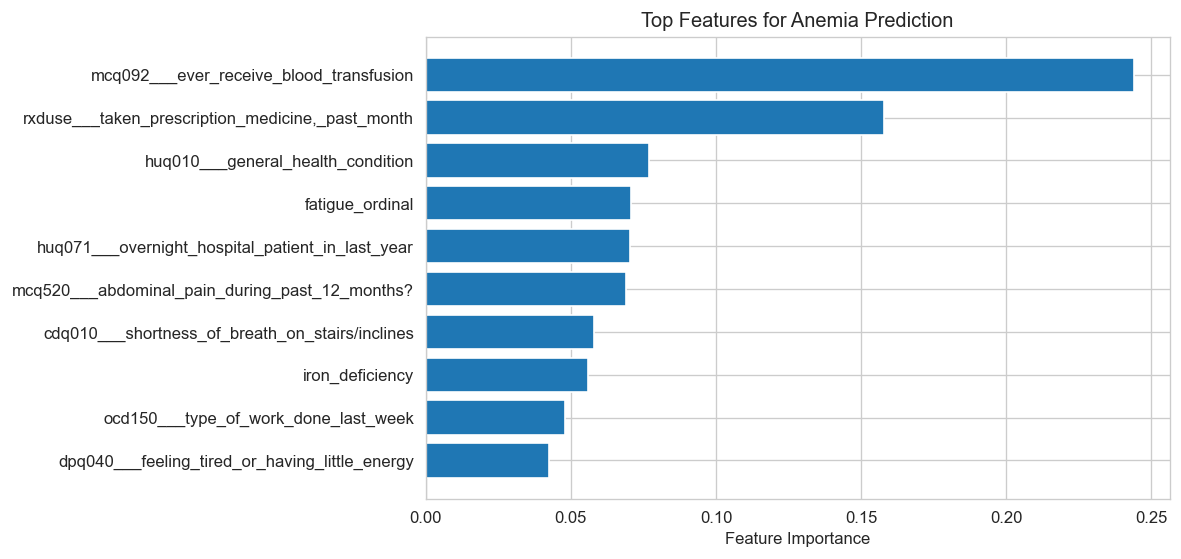

In [52]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top Features for Anemia Prediction")
plt.xlabel("Feature Importance")

plt.show()

### Interpretation of Key Predictive Features

The feature importance analysis highlights several variables that strongly influence the model’s anemia predictions.

The most important predictors include:

- **History of blood transfusion (`mcq092___ever_receive_blood_transfusion`)**  
  Individuals who previously required transfusions are more likely to have experienced anemia or related hematologic conditions.

- **Prescription medication usage (`rxduse___taken_prescription_medicine,_past_month`)**  
  Higher medication usage may indicate underlying chronic conditions associated with anemia.

- **General health condition (`huq010___general_health_condition`)**  
  Self-reported health status is a strong indicator of overall physiological wellbeing.

- **Fatigue-related signals (`fatigue_ordinal`, `dpq040___feeling_tired_or_having_little_energy`)**  
  Fatigue is one of the most common symptoms of anemia.

- **Shortness of breath (`cdq010___shortness_of_breath_on_stairs/inclines`)**  
  Reduced oxygen-carrying capacity in anemia can lead to exertional dyspnea.

- **Iron deficiency (`iron_deficiency`)**  
  Iron deficiency is one of the primary causes of anemia worldwide.

- **Healthcare utilization indicators (`huq071___overnight_hospital_patient_in_last_year`)**  
  Hospitalization may reflect underlying medical conditions that increase anemia risk.

Overall, the model appears to rely on a combination of:

- **clinical laboratory signals**
- **self-reported symptoms**
- **general health indicators**

This combination aligns with medical understanding of anemia and supports the interpretability of the model.

## Final Anemia Prediction Model

### Model Comparison

Three models were evaluated for anemia prediction:

- Logistic Regression (baseline model)
- Random Forest
- Gradient Boosting

The models were compared using recall, precision, F1 score, and ROC-AUC.

| Model | Recall | Precision | ROC-AUC | Notes |
|------|------|------|------|------|
| Logistic Regression | ~0.76 | ~0.08 | ~0.72 | Strong recall but many false positives |
| Random Forest | ~0.21 | ~0.23 | ~0.77 | Very conservative predictions |
| Gradient Boosting | ~0.74 | ~0.13 | ~0.79 | Best overall balance |

Random Forest achieved high accuracy but detected very few anemia cases, making it less suitable for screening.

Logistic Regression achieved high recall but produced many false positives.

Gradient Boosting achieved the best overall balance between recall, precision, and model discrimination.

### Final Model Selection

The final model selected for anemia prediction is:

**Gradient Boosting with a probability threshold of 0.10**

### Final Model Performance

| Metric | Value |
|------|------|
| Accuracy | ~0.75 |
| Precision | ~0.13 |
| Recall | ~0.74 |
| F1 Score | ~0.22 |
| ROC-AUC | ~0.79 |

### Interpretation

The model successfully detects approximately **74% of anemia cases** while maintaining improved precision compared to the baseline model.

Because the system is designed as a **health screening tool rather than a diagnostic model**, prioritizing recall is appropriate. Users flagged as high-risk would be recommended to undergo laboratory testing or consult a physician.

### Key Predictive Signals

Feature importance analysis shows that the model relies on a combination of:

- clinical indicators (iron deficiency, laboratory values)
- symptoms (fatigue, shortness of breath)
- general health indicators (self-reported health status, medication usage)

This combination aligns with medical understanding of anemia risk factors.

### Role in the Application

Within the HalfFull health assessment pipeline:

1. The user answers lifestyle and symptom questions.
2. Optional lab values from routine health checkups can be uploaded.
3. The model estimates anemia risk.
4. If the risk score exceeds the selected threshold, the system recommends further medical evaluation.